In [1]:
pip install numpy opencv-python tensorflow keras matplotlib pillow flask streamlit


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load dataset (Assuming images are stored in 'dataset' folder with subfolders 'jaundice' and 'normal')
DATASET_PATH = "D:\\Juandice_Project\\dataset"
CATEGORIES = ["jaundice", "Non-Jaundice-Augmented"]
IMG_SIZE = (128, 128)

# Function to load images and extract HOG features
def load_and_preprocess_data():
    data = []
    labels = []
    
    for category in CATEGORIES:
        path = os.path.join(DATASET_PATH, category)
        label = CATEGORIES.index(category)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)
            
            # Extract HOG features
            hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')
            
            data.append(hog_features)
            labels.append(label)
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_and_preprocess_data()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

print("Data loaded and preprocessed successfully!")
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")


Data loaded and preprocessed successfully!
Training samples: 1014, Testing samples: 254


In [3]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load dataset (Assuming images are stored in 'dataset' folder with subfolders 'jaundice' and 'normal')
DATASET_PATH = "D:\\Juandice_Project\\dataset"
CATEGORIES = ["jaundice", "Non-Jaundice-Augmented"]
IMG_SIZE = (64, 64)  # Reduced image size for faster processing

# Function to load images and extract HOG features
def load_and_preprocess_data():
    data = []
    labels = []
    
    for category in CATEGORIES:
        path = os.path.join(DATASET_PATH, category)
        label = CATEGORIES.index(category)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)
            
            # Extract HOG features with optimized parameters
            hog_features = hog(img, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm='L2-Hys')
            
            data.append(hog_features)
            labels.append(label)
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_and_preprocess_data()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Train SVM model with linear kernel for faster execution
svm = SVC(kernel='linear', C=1)
svm.fit(X_train, y_train)

# Evaluate model
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Save the trained model
joblib.dump(svm, "svm_model.pkl")

print("Model training and evaluation completed successfully!")


Test Accuracy: 77.17%
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79       136
           1       0.76      0.74      0.75       118

    accuracy                           0.77       254
   macro avg       0.77      0.77      0.77       254
weighted avg       0.77      0.77      0.77       254

Model training and evaluation completed successfully!


In [4]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import joblib

# Load dataset (Assuming images are stored in 'dataset' folder with subfolders 'jaundice' and 'normal')
DATASET_PATH = "D:\\Juandice_Project\\dataset"
CATEGORIES = ["jaundice", "Non-Jaundice-Augmented"]
IMG_SIZE = (64, 64)  # Reduced image size for faster processing

# Function to load images and extract HOG features
def load_and_preprocess_data():
    data = []
    labels = []
    
    for category in CATEGORIES:
        path = os.path.join(DATASET_PATH, category)
        label = CATEGORIES.index(category)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMG_SIZE)
            
            # Extract HOG features with improved parameters
            hog_features = hog(img, pixels_per_cell=(8, 8), cells_per_block=(3, 3), block_norm='L2-Hys')
            
            data.append(hog_features)
            labels.append(label)
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_and_preprocess_data()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Normalize data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model with RBF kernel for better accuracy
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

# Evaluate model
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Save the trained model
joblib.dump(svm, "svm_model.pkl")

print("Model training and evaluation completed successfully!")


Test Accuracy: 83.07%
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84       136
           1       0.82      0.81      0.82       118

    accuracy                           0.83       254
   macro avg       0.83      0.83      0.83       254
weighted avg       0.83      0.83      0.83       254

Model training and evaluation completed successfully!


In [7]:
!pip uninstall -y tensorflow keras  
!pip install tensorflow keras  


Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: keras 3.9.0
Uninstalling keras-3.9.0:
  Successfully uninstalled keras-3.9.0
  Using cached tensorflow-2.19.0-cp311-cp311-win_amd64.whl.metadata (4.1 kB)
  Using cached keras-3.9.0-py3-none-any.whl.metadata (6.1 kB)
Using cached tensorflow-2.19.0-cp311-cp311-win_amd64.whl (375.9 MB)
Using cached keras-3.9.0-py3-none-any.whl (1.3 MB)


In [4]:
!pip uninstall -y tensorflow keras
!pip install tensorflow==2.15.1 keras==2.15.0


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
    --------------------------------------- 0.0/1.7 MB 2.0 MB/s eta 0:00:01
   - -------------------------------------- 0.1/1.7 MB 656.4 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.7 MB 751.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.7 MB 751.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.7 MB 751.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.7 MB 751.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.7 MB 751.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.7 MB 751.6 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.7 MB 751.6 kB/s eta 0:00:03
   ---- ----------------------------------- 0.2/1.7 MB 361.7 kB/s eta 0:00:05
   ----- ---------------------------------- 0.3/1.7 MB 477.2 kB/s eta 0:00:04
   ------- -------------------------------- 0.3/1.7 MB 531.5 kB/s eta 0:00:

In [5]:
import tensorflow as tf
print(tf.__version__)



2.15.1


In [6]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

# Load dataset (Assuming images are stored in 'dataset' folder with subfolders 'jaundice' and 'normal')
DATASET_PATH = "D:\\Juandice_Project\\dataset"
CATEGORIES = ["jaundice", "Non-Jaundice-Augmented"]
IMG_SIZE = (224, 224)  # MobileNetV2 requires 224x224 images

# Function to load and preprocess images
def load_data():
    data = []
    labels = []
    
    for category in CATEGORIES:
        path = os.path.join(DATASET_PATH, category)
        label = CATEGORIES.index(category)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0  # Normalize pixel values
            
            data.append(img)
            labels.append(label)
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_data()

# Encode labels
labels = to_categorical(labels, num_classes=len(CATEGORIES))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load MobileNetV2 as feature extractor
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze last 20 layers for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(len(CATEGORIES), activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
epochs = 20
batch_size = 32
model.fit(train_datagen.flow(X_train, y_train, batch_size=batch_size), validation_data=(X_test, y_test), epochs=epochs, verbose=1)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Save the trained model
model.save("mobilenetv2_model.h5")

print("Model training and evaluation completed successfully!")




9406464/9406464 [==============================] - 7s 1us/step
Epoch 1/20


32/32 [==============================] - 144s 4s/step - loss: 0.5208 - accuracy: 0.7199 - val_loss: 1.0091 - val_accuracy: 0.5748
Epoch 2/20
32/32 [==============================] - 104s 3s/step - loss: 0.2787 - accuracy: 0.8767 - val_loss: 0.7588 - val_accuracy: 0.6654
Epoch 3/20
32/32 [==============================] - 104s 3s/step - loss: 0.2128 - accuracy: 0.9132 - val_loss: 0.5329 - val_accuracy: 0.7717
Epoch 4/20
32/32 [==============================] - 104s 3s/step - loss: 0.1541 - accuracy: 0.9310 - val_loss: 0.6827 - val_accuracy: 0.7362
Epoch 5/20
32/32 [==============================] - 106s 3s/step - loss: 0.1376 - accuracy: 0.9438 - val_loss: 0.5088 - val_accuracy: 0.7953
Epoch 6/20
32/32 [==============================] - 109s 3s/step - loss: 0.0871 - accuracy: 0.9694 - val_loss: 0.4598 - val_accuracy: 0.7717
Epoch 7/20
32/32 [==============================] - 103s 3s/step - loss: 0.0783 - accur

C:\Users\User\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model training and evaluation completed successfully!


Epoch 1/20
32/32 [==============================] - 153s 4s/step - loss: 0.5223 - accuracy: 0.7258 - val_loss: 0.5349 - val_accuracy: 0.7165
Epoch 2/20
32/32 [==============================] - 102s 3s/step - loss: 0.2503 - accuracy: 0.8895 - val_loss: 0.4808 - val_accuracy: 0.7480
Epoch 3/20
32/32 [==============================] - 102s 3s/step - loss: 0.1655 - accuracy: 0.9349 - val_loss: 0.6887 - val_accuracy: 0.6890
Epoch 4/20
32/32 [==============================] - 101s 3s/step - loss: 0.1462 - accuracy: 0.9379 - val_loss: 0.8135 - val_accuracy: 0.6654
Epoch 5/20
32/32 [==============================] - 100s 3s/step - loss: 0.1159 - accuracy: 0.9487 - val_loss: 0.3989 - val_accuracy: 0.7913
Epoch 6/20
32/32 [==============================] - 101s 3s/step - loss: 0.0946 - accuracy: 0.9586 - val_loss: 0.4083 - val_accuracy: 0.8307
Epoch 7/20
32/32 [==============================] - 101s 3s/step - loss: 0.0701 - accuracy: 0.9763 - val_loss: 0.3163 - val_accuracy: 0.8583
Epoch 8/20
32

C:\Users\User\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


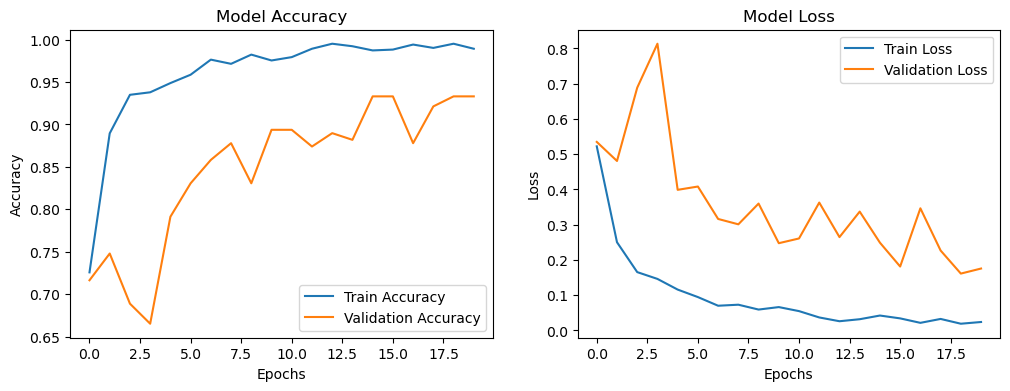

8/8 [==============================] - 9s 727ms/step


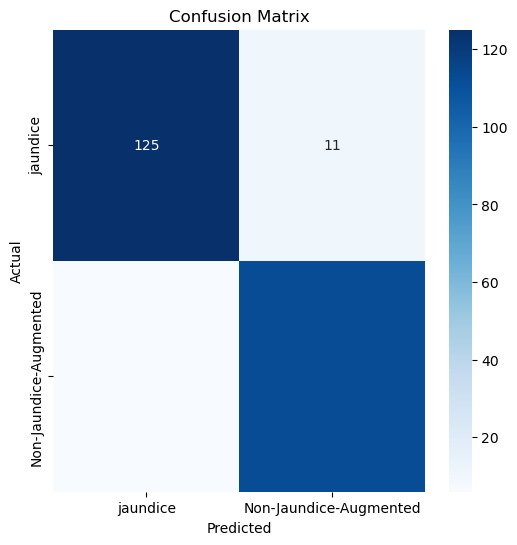

Model training and evaluation completed successfully!


In [7]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import joblib

# Load dataset (Assuming images are stored in 'dataset' folder with subfolders 'jaundice' and 'normal')
DATASET_PATH = "D:\\Juandice_Project\\dataset"
CATEGORIES = ["jaundice", "Non-Jaundice-Augmented"]
IMG_SIZE = (224, 224)  # MobileNetV2 requires 224x224 images

def load_data():
    data = []
    labels = []
    
    for category in CATEGORIES:
        path = os.path.join(DATASET_PATH, category)
        label = CATEGORIES.index(category)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0  # Normalize pixel values
            
            data.append(img)
            labels.append(label)
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_data()
labels = to_categorical(labels, num_classes=len(CATEGORIES))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load MobileNetV2 as feature extractor
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze last 20 layers for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(len(CATEGORIES), activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
epochs = 20
batch_size = 32
history = model.fit(train_datagen.flow(X_train, y_train, batch_size=batch_size), validation_data=(X_test, y_test), epochs=epochs, verbose=1)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Save the trained model
model.save("mobilenetv2_model.h5")

# Plot Accuracy and Loss Graphs
def plot_metrics(history):
    plt.figure(figsize=(12, 4))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Model Accuracy')
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Model Loss')
    
    plt.show()

plot_metrics(history)

# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1))
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

y_pred = model.predict(X_test)
plot_confusion_matrix(y_test, y_pred)

# Function to test a new image
def predict_image(image_path, model_path="mobilenetv2_model.h5"):
    model = load_model(model_path)
    img = load_img(image_path, target_size=IMG_SIZE)
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    
    prediction = model.predict(img)
    predicted_class = CATEGORIES[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    
    plt.imshow(load_img(image_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.show()
    
    return predicted_class, confidence

print("Model training and evaluation completed successfully!")


Epoch 1/20
32/32 [==============================] - 166s 4s/step - loss: 0.5747 - accuracy: 0.6815 - val_loss: 0.4364 - val_accuracy: 0.7717
Epoch 2/20
32/32 [==============================] - 115s 4s/step - loss: 0.2687 - accuracy: 0.8817 - val_loss: 0.3871 - val_accuracy: 0.8228
Epoch 3/20
32/32 [==============================] - 115s 4s/step - loss: 0.1880 - accuracy: 0.9231 - val_loss: 0.3816 - val_accuracy: 0.8189
Epoch 4/20
32/32 [==============================] - 113s 4s/step - loss: 0.1601 - accuracy: 0.9418 - val_loss: 0.3947 - val_accuracy: 0.8346
Epoch 5/20
32/32 [==============================] - 114s 4s/step - loss: 0.1283 - accuracy: 0.9477 - val_loss: 0.3931 - val_accuracy: 0.8346
Epoch 6/20
32/32 [==============================] - 114s 4s/step - loss: 0.0802 - accuracy: 0.9763 - val_loss: 0.3553 - val_accuracy: 0.8386
Epoch 7/20
32/32 [==============================] - 113s 4s/step - loss: 0.0829 - accuracy: 0.9675 - val_loss: 0.4194 - val_accuracy: 0.7795
Epoch 8/20
32

C:\Users\User\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


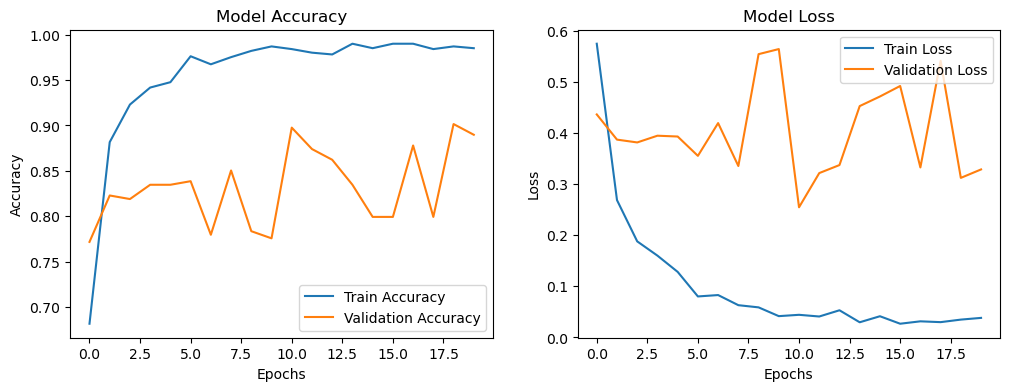

8/8 [==============================] - 7s 644ms/step


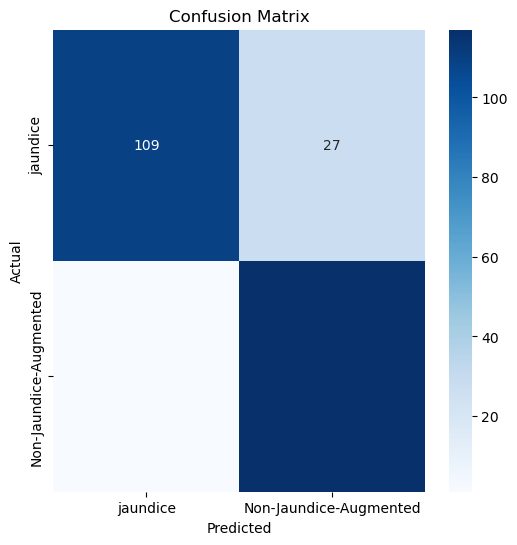

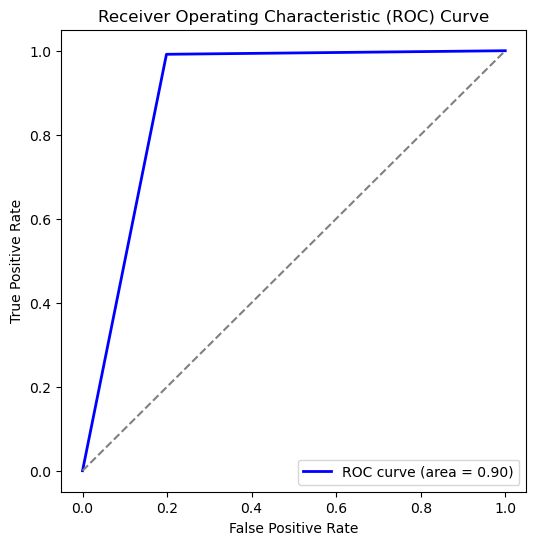

Model training and evaluation completed successfully!


In [8]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib

# Load dataset (Assuming images are stored in 'dataset' folder with subfolders 'jaundice' and 'normal')
DATASET_PATH = "D:\\Juandice_Project\\dataset"
CATEGORIES = ["jaundice", "Non-Jaundice-Augmented"]
IMG_SIZE = (224, 224)  # MobileNetV2 requires 224x224 images

def load_data():
    data = []
    labels = []
    
    for category in CATEGORIES:
        path = os.path.join(DATASET_PATH, category)
        label = CATEGORIES.index(category)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)
            img = cv2.resize(img, IMG_SIZE)
            img = img / 255.0  # Normalize pixel values
            
            data.append(img)
            labels.append(label)
    
    return np.array(data), np.array(labels)

# Load data
data, labels = load_data()
labels = to_categorical(labels, num_classes=len(CATEGORIES))

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Load MobileNetV2 as feature extractor
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze last 20 layers for fine-tuning
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(len(CATEGORIES), activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=x)
model.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

# Train model
epochs = 20
batch_size = 32
history = model.fit(train_datagen.flow(X_train, y_train, batch_size=batch_size), validation_data=(X_test, y_test), epochs=epochs, verbose=1)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Save the trained model
model.save("mobilenetv2_model.h5")

# Plot Accuracy and Loss Graphs
def plot_metrics(history):
    plt.figure(figsize=(12, 4))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Model Accuracy')
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Model Loss')
    
    plt.show()

plot_metrics(history)

# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1))
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

y_pred = model.predict(X_test)
plot_confusion_matrix(y_test, y_pred)

# ROC Curve
def plot_roc_curve(y_true, y_pred):
    fpr, tpr, _ = roc_curve(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1))
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

plot_roc_curve(y_test, y_pred)

# Function to test a new image
def predict_image(image_path, model_path="mobilenetv2_model.h5"):
    model = load_model(model_path)
    img = load_img(image_path, target_size=IMG_SIZE)
    img = img_to_array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    
    prediction = model.predict(img)
    predicted_class = CATEGORIES[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    
    plt.imshow(load_img(image_path))
    plt.axis('off')
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.show()
    
    return predicted_class, confidence

print("Model training and evaluation completed successfully!")
